# Make figure for MPAS-O and ROMS Kinetic Energy Time Series and Spectra

In [ ]:
import xarray as xr
import xroms
import xgcm
from xhistogram.xarray import histogram

import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import os
import time

from scipy import signal

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import dask
from dask.distributed import Client

client = Client()
client

## Load MPAS-O data

In [6]:
mroots = [
         '/mpaso_channel/10km/',
         '/mpaso_channel/5km/',
         '/mpaso_channel/2km/',
         '/mpaso_channel/1km/',
         '/mpaso_channel/500m/',    
         '/mpaso_channel/200m/',
         '/mpaso_channel/100m/'
]

In [7]:
mds = []
mdsg = []
mverts = []
midx = []
mnorm = []
for rootdir in mroots:
    ds_mpas = xr.open_dataset(rootdir + 'output.nc', chunks={'Time': 1})
    dsg = xr.open_dataset(rootdir + 'channel_init.nc')
    ds_mpas['normalizedRelativeVorticity'] = ds_mpas.relativeVorticityCell / dsg.fCell
    ds_mpas['normalizedDivergence'] = ds_mpas.divergence / dsg.fCell
    mds.append(ds_mpas)
    mdsg.append(dsg)

    verts = np.dstack((dsg.xVertex.values[dsg.verticesOnCell-1],
                       dsg.yVertex.values[dsg.verticesOnCell-1]))
    nverts = np.sum(dsg.verticesOnCell != 0, axis=1).values
    verts = [vert[:n] for vert, n in zip(verts, nverts)]
    idx = [(np.abs(vert[:, 0].ptp()) < 50000) for vert in verts]
    midx.append(idx)
    verts = np.array(verts)[idx]
    mverts.append(verts)

    norm = plt.matplotlib.colors.Normalize(-3, 3)
    mnorm.append(norm)

In [8]:
res_lgd = ['10 km', '5 km', '2 km', '1 km', '500 m', '200 m']

### Calculate surface KE for MPAS-O

In [ ]:
# Loop over MPAS-O outputs and calculate average KE from variable kineticEnergyCell

mkes = []
for axi in range(len(mds)):
    ympas = mdsg[axi].yCell.values
    # Only calculate kinetic energy 50 km away from the walls of the model domain
    idx = np.where(np.logical_and(ympas>50000, ympas<250000))
    mpas_ke = mds[axi].kineticEnergyCell.isel(
                nVertLevels=0, nCells=slice(idx[0][0], idx[0][-1])).mean(dim='nCells').compute()
    mkes.append(mpas_ke)


## Calculate volume integrated EKE for MPAS-O

In [ ]:
# === Processing Loop ===
mpas_ekes = []

resolutions = [[10000, 5000, 2000, 1000, 500, 200, 100]
layers = [50]


def volume_weighted_zonal_mean(var, weight):
    """
    Zonal (x-periodic) mean via meridional (yBin) binning, weighted by
    `weight` (areaCell * layerThickness), consistent with the volume
    integral used downstream for EKE.
    """
    weighted_sum = (var * weight).groupby("yBin").sum("nCells")
    weight_sum = weight.groupby("yBin").sum("nCells")
    return weighted_sum / weight_sum


for res in range(len(resolutions)):

    dx = resolutions[res]  # resolution in meters

    # Load datasets
    dso_masked = mds[res]
    dsg_masked = mdsg[res]
    dso_masked['Time'] = mds[res].xtime  # Fix Time coordinate

    conditional = (dsg.yCell > (50e3)) & (dsg.yCell < (250e3))

    # === Adaptive bin width ===
    dy = max(10 * dx, 5000)  # see NOTE above re: cross-resolution comparisons
    y_vals = dsg_masked["yCell"].data
    y_bins = np.arange(y_vals.min(), y_vals.max() + dy, dy)
    bin_indices = np.digitize(y_vals, y_bins)
    bin_labels = xr.DataArray(bin_indices, dims=["nCells"])

    dso_masked = dso_masked.assign_coords(yBin=bin_labels)
    dsg_masked = dsg_masked.assign_coords(yBin=bin_labels)

    area_cell = dsg_masked["areaCell"]
    layer_thickness = dsg_masked["layerThickness"]

    # Weight for the zonal mean = volume element (area * thickness),
    # matching the weighting used in the EKE volume integral below
    weight = area_cell * layer_thickness

    u_bar = volume_weighted_zonal_mean(dso_masked["velocityZonal"], weight)
    v_bar = volume_weighted_zonal_mean(dso_masked["velocityMeridional"], weight)

    # Broadcast zonal means back to grid
    u_bar_cell = u_bar.sel(yBin=bin_labels).transpose("Time", "nVertLevels", "nCells")
    v_bar_cell = v_bar.sel(yBin=bin_labels).transpose("Time", "nVertLevels", "nCells")

    # === EKE Calculation ===
    eke = 0.5 * ((dso_masked["velocityZonal"] - u_bar_cell) ** 2 +
                 (dso_masked["velocityMeridional"] - v_bar_cell) ** 2) * layer_thickness * area_cell

    # MKE needed only for normalization (initial-time norm factor)
    mke = 0.5 * (u_bar_cell ** 2 + v_bar_cell ** 2) * layer_thickness * area_cell

    eke_ts = eke.where(conditional).sum(dim=["nCells", "nVertLevels"])
    mke_ts = mke.where(conditional).sum(dim=["nCells", "nVertLevels"])

    # Normalize by initial MKE at first time index
    norm_factor = mke_ts.isel(Time=0)
    eke_ts = (eke_ts / norm_factor).compute()
    mpas_ekes.append(eke_ts)


In [ ]:
rainbow_cmap = np.asarray([[165,0,38],
                         [215,48,39],
                         [253,174,97],
                         [0,0,0],
                         [171,217,233],
                         [116,173,209],
                         [49,54,149]]) / 255


Text(0.5, 1.0, 'MPAS-O')

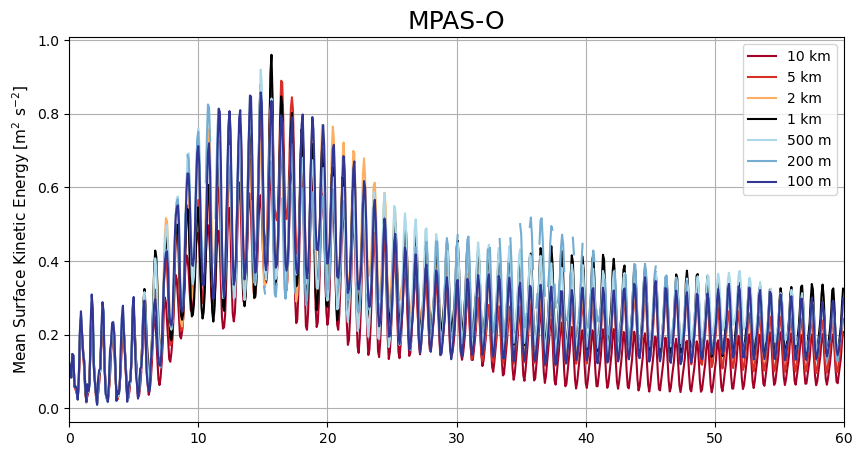

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

ndays = 60
tsteps = ndays * 12

t = np.linspace(0, ndays-2/24, int(ndays/(2/24)))

for iplot in range(len(mkes)):
    if iplot==5:
        mpas_ke = mkes[iplot]
    elif iplot!=5:
        mpas_ke = mkes[iplot] #/ 1025
    ax.plot(t[0:len(mpas_ke)], mpas_ke[:tsteps], label=res_lgd[iplot],
           color=rainbow_cmap[iplot,:])

ax.set_xlim(0, 60)
ax.grid(True)

ax.set_ylabel('Mean Surface Kinetic Energy [m$^{2}$ s$^{-2}$]', fontsize=11)
ax.legend(loc='upper right')
ax.set_title('MPAS-O', fontsize=18, loc='center')


## Load ROMS data

In [ ]:
roms_files = [
         '/roms_channel/10km/roms_his.nc',
         '/roms_channel/5km/roms_his.nc',
         '/roms_channel/2km/roms_his.nc',
         '/roms_channel/1km/roms_his.nc',
         '/roms_channel/500m/roms_his.nc',
         '/roms_channel/200m/roms_his.nc',
         '/roms_channel/100m/roms_his.nc',
        ]


In [ ]:
# Load and calculate KE and EKE for ROMS datasets using xroms

dss = []
xgrids = []
for file in roms_files:
    ds = xr.open_dataset(file, chunks={'ocean_time': 1})
    ds, xgrid = xroms.roms_dataset(ds)
    speed = xroms.speed(ds.u, ds.v, xgrid)
    KE = xroms.KE(ds.rho0, speed)
    ds['ke'] = KE
    ds = ds.isel(s_rho=-1)
    dss.append(ds)
    xgrids.append(xgrid)

### Calculate average ROMS surface kinetic energy values for all resolutions

In [10]:
ke_roms = []

for axi in range(len(dss)):
    # Only calculate kinetic energy 50 km away from the walls of the model domain
    conditional = (dss[axi].y_rho > 50e3) & (dss[axi].y_rho < 250e3)
    grab_ke = dss[axi].ke.where(conditional)
    calc_ke = grab_ke.mean(dim=['xi_rho', 'eta_rho']).compute()

    ke_roms.append(calc_ke)

## Calculate depth integrated ROMS eddy kinetic energy

In [ ]:
# Define multiple functions to compute EKE, within specified bounds

def energy_vint(ds,grid,etaslice,xislice):
    '''
Calculates volume-integrated eddy, mean, and total kinetic energy. Modified from Hetland (2017) JPO.
Notes:
------
EKE = 1/2(uprime^2 + vprime^2). 
MKE = 1/2(ubar^2+vbar^2)
TKE = 1/2(u^2+v^2)
u = ubar+uprime, ubar = 1/L int_0^L u dx, i.e., alongshore mean
v = vbar+vprime
Velocities interpolated to their respective rho points
    '''
    u = xroms.to_rho(ds.u, grid)
    urho = u.isel(eta_rho = etaslice, xi_rho = xislice) 
    v = xroms.to_rho(ds.v, grid)
    vrho = v.isel(eta_rho = etaslice, xi_rho = xislice)
    
    ubar = urho.mean('xi_rho')
    uprime = urho-ubar
    
    vbar = vrho.mean('xi_rho')
    vprime = vrho-vbar
    
    dV = ds.dV.isel(eta_rho = etaslice, xi_rho = xislice)
    #Mean kinetic energy
    mke = 0.5*(ubar**2+vbar**2)
    mke_initial = (mke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])[0] # Initial value for normalization

    #Eddy kinetic energy
    eke = 0.5*(uprime**2 + vprime**2)
    eke_int = (eke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    eke_norm = (eke_int / mke_initial).compute()
    
    return eke_norm

# Loop to get indices of y bounds for analyses
eta_idxs = []
for dgrab in dss:
    eta_grab = np.asarray(dgrab.y_rho.isel(xi_rho=0))
    eta_first = np.searchsorted(eta_grab, 50_000, side="left")
    eta_last = np.searchsorted(eta_grab, 50_000, side="right") - 1
    eta_idxs.append([eta_first,eta_last])

# Run the functions
# -----------------
xislice = slice(1,-1)

roms_ekes = []
for ii in range(len(dss)):
    ds_grab = dss[ii]
    etaslice = slice(eta_idxs[ii][0],(eta_idxs[ii][1]+1))
    roms_ekes.append(energy_vint(dss[ii],xgrids[ii],etaslice,xislice))

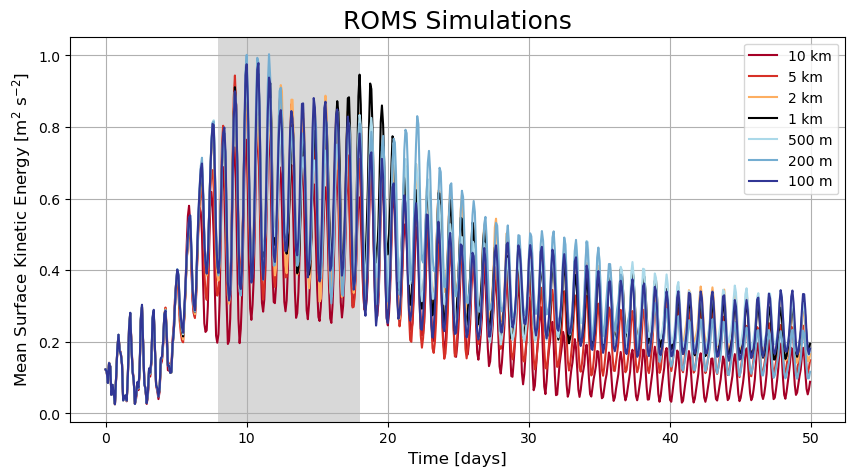

In [ ]:
### ROMS Kinetic Energy Plot

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

ndays = 50
tsteps = ndays * 12
t = np.linspace(0, ndays-2/24, int(ndays/(2/24)))
for iplot in range(len(ke_roms)):
    # roms_grab = ke_roms[iplot] / dss[0].rho0.values
    roms_grab = ke_roms[iplot] / 1025
    ax.plot(t[0:len(roms_grab)], roms_grab[:tsteps],
            label=res_lgd[iplot], color=rainbow_cmap[iplot,:])
ax.grid(True)
ax.set_xlabel('Time [days]', fontsize=12)
ax.set_ylabel('Mean Surface Kinetic Energy [m$^{2}$ s$^{-2}$]', fontsize=12)
ax.legend(loc='upper right')
ax.set_title('ROMS Simulations', fontsize=18, loc='center')
ax.axvspan(8, 18, color='grey', alpha=0.3, lw=0)


## Power Spectral Density Computations

In [ ]:
### MPAS-O Power Densities

f_mpas = []
pden_mpas = []

for rds in mkes:
    cell_len = len(rds.nCells)
    f_arr = np.zeros((129, cell_len))
    pden_arr = np.zeros((129, cell_len))

    ke_grab = rds.values

    for i in range(cell_len):
        bb = ke_grab[:,i]
        f0, Pxx_den0 = signal.welch(bb, 12)
        f_arr[:,i] = f0
        pden_arr[:,i] = Pxx_den0

    f_mpas.append(f_arr.mean(axis=1))
    pden_mpas.append(pden_arr.mean(axis=1))

In [ ]:
### ROMS Power Densities

f_roms = []
pden_roms = []

for rds in dss:
    xi_len = len(rds.xi_rho)
    eta_len = len(rds.eta_rho)
    f_arr = np.empty((129, eta_len, xi_len))
    pden_arr = np.empty((129, eta_len, xi_len))
    f_arr[:] = np.nan
    pden_arr[:] = np.nan

    conditional = (rds.y_rho > 50e3) & (rds.y_rho < 250e3)
    ke_grab = rds.ke.where(conditional).values

    for i in range(xi_len):
        for j in range(eta_len):
            f0, Pxx_den0 = signal.welch((ke_grab[:,j,i]/1025), 12)
            f_arr[:,j,i] = f0
            pden_arr[:,j,i] = Pxx_den0


    f_roms.append(np.nanmean(f_arr, axis=(1, 2)))
    pden_roms.append(np.nanmean(pden_arr, axis=(1, 2)))

## Plot Surface KE and EKE for both models

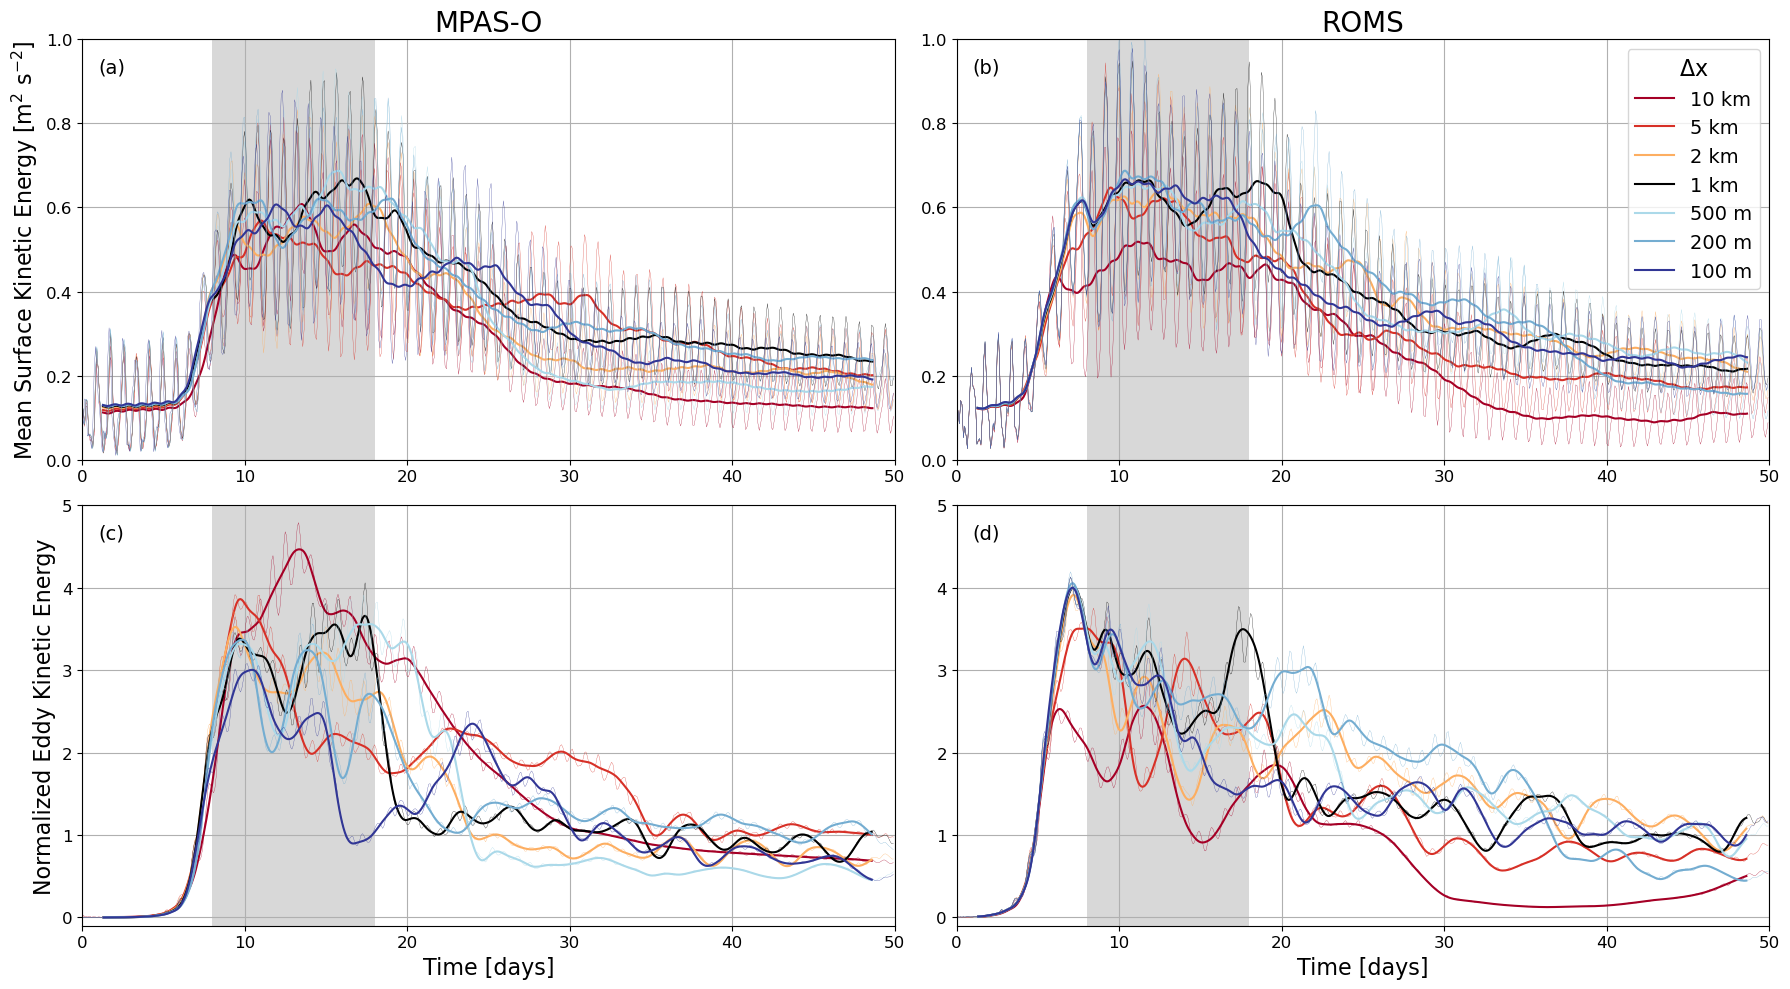

In [ ]:
fig = plt.figure(figsize=(18, 10))

# specify time axis
ndays = 50
tsteps = ndays * 12
t = np.linspace(0, ndays-2/24, int(ndays/(2/24)))

# ----------------------------------------------------------------------- #
### Surface KE Plots ###
# ----------------------------------------------------------------------- #
### MPAS-O Kinetic Energy ###

ax = fig.add_subplot(221)

icolor = 0
for iplot in range(len(mkes)):
    mpas_ke = pl33tn(mkes[iplot], dt=2)
    tadjust = (len(t) - len(mpas_ke)) / 24
    ax.plot(t[0:len(mpas_ke)]+tadjust, mpas_ke[:tsteps], label=res_lgd[iplot],
           color=rainbow_cmap[icolor,:])
    raw_mkes = mkes[iplot]
    ax.plot(t[0:len(raw_mkes)], raw_mkes[:tsteps], label='', linewidth=0.2,
           color=rainbow_cmap[icolor,:])
    icolor+=1
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 50)
ax.grid(True)
ax.set_ylabel('Mean Surface Kinetic Energy [m$^{2}$ s$^{-2}$]', fontsize=16)
ax.set_title('MPAS-O', fontsize=20, loc='center')
ax.text(1, 0.92, '(a)', fontsize=14)
ax.axvspan(8, 18, color='grey', alpha=0.3, lw=0)
ax.tick_params(axis='both', labelsize=12)

# --------------------------------------------------------------#
### ROMS Kinetic Energy ###

ax = fig.add_subplot(222)

icolor = 0
for iplot in range(len(ke_roms)):
    roms_ke = pl33tn(ke_roms[iplot]/1025, dt=2)
    tadjust = (len(t) - len(roms_ke)) / 24
    ax.plot(t[0:len(roms_ke)]+tadjust, roms_ke[:tsteps], label=res_lgd[iplot],
           color=rainbow_cmap[icolor,:])
    raw_rke = ke_roms[iplot]/1025
    ax.plot(t[0:len(raw_rke)], raw_rke[:tsteps], label='', linewidth=0.2,
       color=rainbow_cmap[icolor,:])
    icolor+=1
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 50)
ax.grid(True)
l1 = ax.legend(loc='upper right', title='$\Delta$x',fontsize=14)
l1.get_title().set_fontsize('16')
ax.set_title('ROMS', fontsize=20, loc='center')
ax.text(1, 0.92, '(b)', fontsize=14)
ax.axvspan(8, 18, color='grey', alpha=0.3, lw=0)
ax.tick_params(axis='both', labelsize=12)

# ----------------------------------------------------------------------- #
### EKE Plots ###
# ----------------------------------------------------------------------- #
### MPAS-O Eddy Kinetic Energy ###

ax = fig.add_subplot(223)

icolor = 0
for iplot in range(len(mpas_ekes)):
    mpas_eke = pl33tn(mpas_ekes[iplot].values[0:600], dt=2)
    tadjust = (len(t) - len(mpas_eke)) / 24
    ax.plot(t[0:len(mpas_eke)]+tadjust, mpas_eke[:tsteps], label=res_lgd[iplot],
           color=rainbow_cmap[icolor,:])
    raw_mekes = mpas_ekes[iplot].values#[0:600]
    ax.plot(t[0:len(raw_mekes)], raw_mekes[:tsteps], label='', linewidth=0.2,
           color=rainbow_cmap[icolor,:])
    icolor+=1

ax.set_xlim(0, 50)
ax.set_ylim([-0.1,5])
ax.grid(True)
ax.set_ylabel('Normalized Eddy Kinetic Energy', fontsize=16)
ax.set_xlabel('Time [days]', fontsize=16)
ax.axvspan(8, 18, color='grey', alpha=0.3, lw=0)
ax.text(1, 4.6, '(c)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# -------------------------------------------------------------- #
### ROMS Eddy Kinetic Energy ###

ax = fig.add_subplot(224)

icolor = 0
for iplot in range(len(roms_ekes)):
    reke_grab = roms_ekes[iplot].eke.values[0:600]
    roms_eke = pl33tn(reke_grab, dt=2)
    tadjust = (len(t) - len(roms_eke)) / 24
    ax.plot(t[0:len(roms_eke)]+tadjust, roms_eke[:tsteps], label=res_lgd[iplot],
           color=rainbow_cmap[icolor,:])
    ax.plot(t[0:len(reke_grab)], reke_grab[:tsteps], label='', linewidth=0.2,
       color=rainbow_cmap[icolor,:])
    icolor+=1

ax.set_xlim(0, 50)
ax.set_ylim([-0.1,5])

ax.grid(True)
ax.set_xlabel('Time [days]', fontsize=16)
ax.axvspan(8, 18, color='grey', alpha=0.3, lw=0)
ax.text(1, 4.6, '(d)', fontsize=14)
ax.tick_params(axis='both', labelsize=12)


## Make Kinetic Energy Spectra Plot

In [ ]:
# Highlight 1 km resolution simulation, make other resolutions lighter in color
pinkcolor = np.divide([254, 204, 204], 255)
greycolor = np.divide([207, 207, 207], 255)
pinkcolor = [1, 0.8, 0.8]
greycolor = [0.8, 0.8, 0.8]

In [ ]:
# Calculate frequency of wind forcing and add to plot
windfrc = 1E-4/(2*np.pi)*86400
wf_line = windfrc*0.9
f_line = windfrc

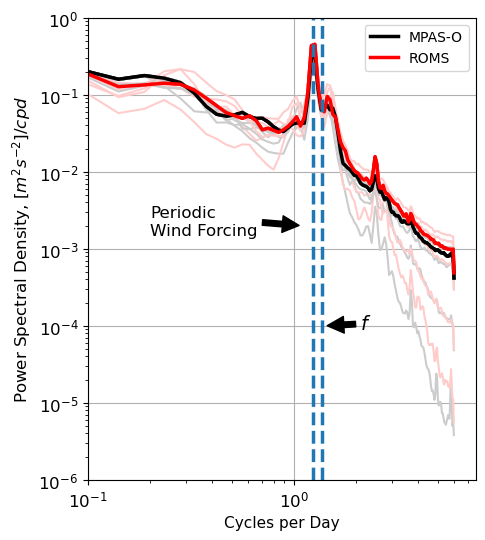

In [ ]:
# Make surface KE spectra plot

fig = plt.figure(figsize=(5,6))
ax = fig.add_subplot(111)

res_pop = 3 # Highlight 1-km simulations for both MPAS-O and ROMS

ax.loglog(mpas_fs[res_pop], mpas_pden[res_pop], 'k', label='MPAS-O', linewidth=2.5)
ax.loglog(roms_fs[res_pop], roms_pden[res_pop], 'r', label='ROMS', linewidth=2.5)
for i in range(len(res_lgd)):
    if i==4:
        continue
    else:
        ax.loglog(mpas_fs[i], mpas_pden[i], color=greycolor)
        ax.loglog(roms_fs[i], roms_pden[i], color=pinkcolor)

ax.loglog(mpas_fs[res_pop], mpas_pden[res_pop], 'k', linewidth=2.5)
ax.loglog(roms_fs[res_pop], roms_pden[res_pop], 'r', linewidth=2.5)
ax.axvline(wf_line, linewidth=2.5, linestyle='--')
ax.axvline(f_line, linewidth=2.5, linestyle='--')

ax.annotate('Periodic\nWind Forcing', xy=(wf_line-0.15, 2E-3), xytext=(0.2, 1.5E-3),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)
ax.annotate('$f$', xy=(f_line+0.05, 1E-4), xytext=(2.1, 9E-5),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=14)
ax.set_xlim(left=1e-1)
ax.set_ylim([1e-6, 1E0])
ax.set_xlabel('Cycles per Day', fontsize=11)
ax.set_ylabel(r'Power Spectral Density, $[m^2 s^{-2}]/cpd$', fontsize=12)
ax.legend()
ax.grid()
